# Unsupervised Learning — Theory (README Chapter V, task 1)

This notebook answers the four questions posed in the **Preamble** and the
**Introduction** of the project README:

1. For which of the already studied models is the **curse of dimensionality** relevant, and why?
2. What is the difference between **PCA** and **SVD**?
3. What is the difference between **NMF** and **SVD**?
4. Describe the structure of the **Locally Linear Embedding (LLE)** algorithm.

Every answer is backed by a computation run in this notebook rather than by prose alone:
a distance-concentration experiment and a noise-feature stress test for Q1, exact
numerical identities between `PCA` and `numpy.linalg.svd` for Q2, side-by-side learned
components on `load_digits` for Q3, and a from-scratch re-implementation of the two
optimisation steps of LLE checked against scikit-learn for Q4.

Only datasets bundled with scikit-learn are used (`load_digits`, `make_swiss_roll`), so
the notebook runs offline in a couple of minutes.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.linalg import eigh, orthogonal_procrustes
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr

from sklearn.datasets import load_digits, make_swiss_roll
from sklearn.decomposition import NMF, PCA, TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold._locally_linear import barycenter_kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Minimal chart style: recessive axes/grid, colors assigned in fixed order.
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "font.size": 10, "figure.dpi": 100,
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

NB_START = time.perf_counter()
print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


## Question 1. For which of the already studied models is the curse of dimensionality relevant, and why?

The track so far has covered **linear / logistic regression, k-NN, Naive Bayes, SVM,
CART decision trees, Random Forest, ExtraTrees and GBDT (LightGBM / XGBoost / CatBoost)**.
Two experiments separate them.

**Experiment 1.1 — distance concentration.** Sample $n$ points uniformly in the unit cube
$[0,1]^d$ and look, for a query point, at the nearest and the farthest neighbour distance.
The quantity that matters for every distance-based method is the *relative contrast*

$$\text{contrast} = \frac{d_{\max} - d_{\min}}{d_{\min}},$$

i.e. how much farther the farthest point is than the nearest one, *in relative terms*.
Beyer et al. (1999) proved this collapses to $0$ as $d \to \infty$ for i.i.d. features —
"nearest neighbour" stops being a meaningful notion.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)

n_points, n_queries = 1000, 200
dims = [2, 5, 10, 50, 100, 500, 1000]
rows = []

for d in dims:
    X = rng.random((n_points, d))
    Q = rng.random((n_queries, d))
    # full query-to-sample distance matrix, then per-query min / max
    D = cdist(Q, X, metric="euclidean")
    d_min, d_max = D.min(1), D.max(1)
    rows.append({
        "d": d,
        "mean d_min": d_min.mean(),
        "mean d_max": d_max.mean(),
        "contrast (dmax-dmin)/dmin": ((d_max - d_min) / d_min).mean(),
        "ratio d_min/d_max": (d_min / d_max).mean(),
    })

contrast = pd.DataFrame(rows).set_index("d")
contrast.round(4)

,mean d_min,mean d_max,contrast (dmax-dmin)/dmin,ratio d_min/d_max
d,,,,
2,0.0164,1.0478,93.2320,0.0158
5,0.1828,1.4845,7.7222,0.1235
10,0.5078,1.9138,2.8645,0.2653
50,2.1051,3.5563,0.6930,0.5920
100,3.3283,4.7788,0.4367,0.6966
500,8.3962,9.8379,0.1719,0.8535
1000,12.1732,13.6235,0.1192,0.8936


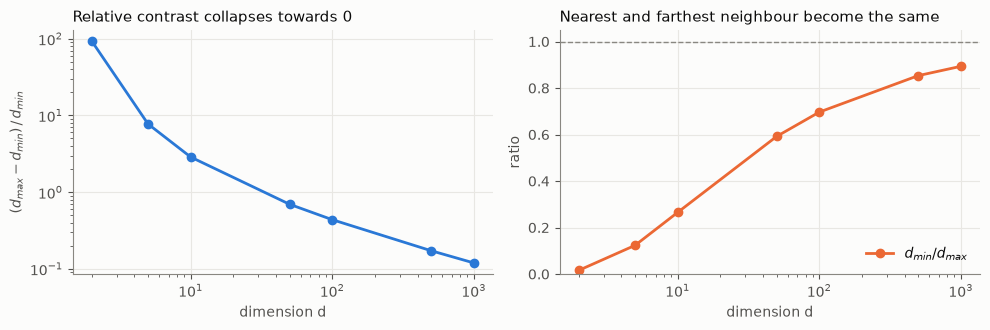

d=2   : the farthest point is 93.2x farther than the nearest (in relative terms)
d=1000: only 0.12x — d_min/d_max = 0.894


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

ax = axes[0]
ax.plot(contrast.index, contrast["contrast (dmax-dmin)/dmin"], "o-", color=C_BLUE, lw=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("dimension d")
ax.set_ylabel(r"$(d_{max}-d_{min})\,/\,d_{min}$")
ax.set_title("Relative contrast collapses towards 0", loc="left", fontsize=11)

ax = axes[1]
ax.plot(contrast.index, contrast["ratio d_min/d_max"], "o-", color=C_ORANGE, lw=2,
        label=r"$d_{min}/d_{max}$")
ax.axhline(1.0, color=MUTED, ls="--", lw=1)
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.set_xlabel("dimension d")
ax.set_ylabel("ratio")
ax.set_title("Nearest and farthest neighbour become the same", loc="left", fontsize=11)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"d=2   : the farthest point is {contrast.loc[2, 'contrast (dmax-dmin)/dmin']:.1f}x "
      f"farther than the nearest (in relative terms)")
print(f"d=1000: only {contrast.loc[1000, 'contrast (dmax-dmin)/dmin']:.2f}x — "
      f"d_min/d_max = {contrast.loc[1000, 'ratio d_min/d_max']:.3f}")

**Experiment 1.2 — appending pure noise features.** `load_digits` (1797 images, 64 real
pixel features, 10 classes) is stressed by concatenating $m$ columns of pure Gaussian
noise, $m \in \{0, 16, 64, 256, 1024\}$. The *signal* is unchanged — every model could in
principle ignore the new columns — so any accuracy drop is the curse of dimensionality
and nothing else. Fit time is recorded as well, because the README also lists the cost
in time and memory as a symptom.

In [4]:
X_digits, y_digits = load_digits(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=RANDOM_STATE, stratify=y_digits)

# noise on the same scale as the pixel values (0..16) so it cannot be filtered by scale alone
NOISE_SCALE = 8.0
noise_levels = [0, 16, 64, 256, 1024]

model_factories = {
    "k-NN (k=5)":       lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "SVM (RBF)":        lambda: make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE)),
    "Logistic reg.":    lambda: make_pipeline(StandardScaler(),
                                              LogisticRegression(max_iter=2000,
                                                                 random_state=RANDOM_STATE)),
    "Gaussian NB":      lambda: GaussianNB(),
    "Decision tree":    lambda: DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random forest":    lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                       random_state=RANDOM_STATE),
    "HistGBDT":         lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

acc_records, time_records = [], []
noise_rng = np.random.default_rng(RANDOM_STATE)

for m in noise_levels:
    N_tr = noise_rng.standard_normal((len(X_tr), m)) * NOISE_SCALE
    N_te = noise_rng.standard_normal((len(X_te), m)) * NOISE_SCALE
    A_tr, A_te = np.hstack([X_tr, N_tr]), np.hstack([X_te, N_te])

    acc_row, time_row = {"noise features": m}, {"noise features": m}
    for name, factory in model_factories.items():
        t0 = time.perf_counter()
        model = factory().fit(A_tr, y_tr)
        time_row[name] = time.perf_counter() - t0
        acc_row[name] = model.score(A_te, y_te)
    acc_records.append(acc_row)
    time_records.append(time_row)
    print(f"noise features = {m:5d} done", flush=True)

acc = pd.DataFrame(acc_records).set_index("noise features")
fit_time = pd.DataFrame(time_records).set_index("noise features")
print("\nTest accuracy (64 informative pixels + m noise columns):")
acc.round(4)

noise features =     0 done


noise features =    16 done


noise features =    64 done


noise features =   256 done


noise features =  1024 done



Test accuracy (64 informative pixels + m noise columns):


,k-NN (k=5),SVM (RBF),Logistic reg.,Gaussian NB,Decision tree,Random forest,HistGBDT
noise features,,,,,,,
0,0.9704,0.9833,0.9815,0.8222,0.8519,0.9685,0.9593
16,0.9556,0.9796,0.9685,0.8278,0.8222,0.9667,0.9593
64,0.9185,0.9630,0.9333,0.8259,0.8278,0.9574,0.9593
256,0.7870,0.9241,0.9037,0.8278,0.8296,0.9519,0.9481
1024,0.4537,0.8630,0.8333,0.8370,0.8074,0.9204,0.9426


In [5]:
drop = (acc.loc[0] - acc.loc[noise_levels[-1]]).sort_values(ascending=False)
summary = pd.DataFrame({
    "accuracy, 0 noise": acc.loc[0],
    f"accuracy, {noise_levels[-1]} noise": acc.loc[noise_levels[-1]],
    "absolute drop": drop,
    "fit time x (last / first)": fit_time.loc[noise_levels[-1]] / fit_time.loc[0],
}).sort_values("absolute drop", ascending=False)
summary.round(4)

,"accuracy, 0 noise","accuracy, 1024 noise",absolute drop,fit time x (last / first)
k-NN (k=5),0.9704,0.4537,0.5167,7.2112
Logistic reg.,0.9815,0.8333,0.1481,14.3526
SVM (RBF),0.9833,0.8630,0.1204,15.7300
Random forest,0.9685,0.9204,0.0481,2.0412
Decision tree,0.8519,0.8074,0.0444,45.7419
HistGBDT,0.9593,0.9426,0.0167,12.6307
Gaussian NB,0.8222,0.8370,-0.0148,18.2184


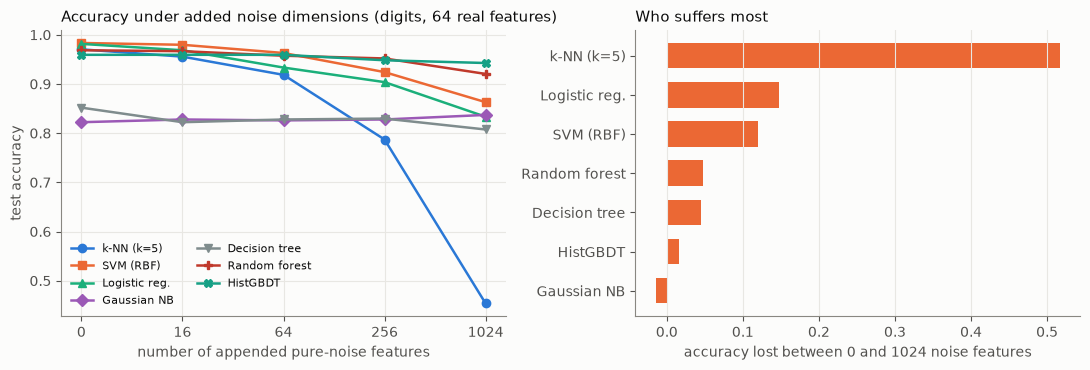

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
palette = [C_BLUE, C_ORANGE, C_AQUA, "#9b59b6", "#7f8c8d", "#c0392b", "#16a085"]
markers = ["o", "s", "^", "D", "v", "P", "X"]

ax = axes[0]
for (name, col), color, mk in zip(acc.items(), palette, markers):
    ax.plot(range(len(acc.index)), col.values, marker=mk, color=color, lw=1.8, label=name)
ax.set_xticks(range(len(acc.index)))
ax.set_xticklabels(acc.index)
ax.set_xlabel("number of appended pure-noise features")
ax.set_ylabel("test accuracy")
ax.set_title("Accuracy under added noise dimensions (digits, 64 real features)",
             loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, ncol=2)

ax = axes[1]
order = summary.index
ax.barh(range(len(order)), summary["absolute drop"].values, color=C_ORANGE, height=0.65)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel("accuracy lost between 0 and 1024 noise features")
ax.set_title("Who suffers most", loc="left", fontsize=11)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

**Answer 1.** The curse of dimensionality hurts a model exactly to the degree that the
model's decision rule depends on **all** coordinates at once, and it is mild for models
that select coordinates or that shrink/average over them.

**Badly affected — everything built on a distance or a kernel over the full feature
vector: k-NN, SVM with an RBF kernel, and (in the next chapters) k-means, DBSCAN, t-SNE,
UMAP.** Experiment 1.1 is the mechanism: with i.i.d. coordinates the squared distance
$\|x-y\|^2=\sum_{j=1}^{d}(x_j-y_j)^2$ is a sum of $d$ i.i.d. terms, so its mean grows like
$d$ while its standard deviation grows only like $\sqrt{d}$; the coefficient of variation
decays as $1/\sqrt{d}$ and every pair of points ends up at nearly the same distance. The
relative contrast measured above falls from
$\mathbf{93}$ at $d=2$ to $\mathbf{0.12}$ at $d=1000$, and $d_{\min}/d_{\max}$
climbs from $\mathbf{0.016}$ to $\mathbf{0.89}$ — the nearest of a thousand points is
already 89 % as far away as the farthest one. Once that happens, "the 5 nearest neighbours"
is essentially a random subset of the sample and the RBF kernel
$\exp(-\gamma\|x-y\|^2)$ becomes nearly constant across all pairs. Experiment 1.2 confirms
it: k-NN falls from **0.970 to 0.454** — the single worst collapse in the table — and
SVM-RBF from **0.983 to 0.863**, even though not a single informative pixel was removed.
Worse, distance-based methods have no notion of "feature importance" at all: they cannot
down-weight a useless coordinate, because every coordinate enters the sum with weight one.

**Moderately affected — linear and logistic regression.** These are not distance-based,
but the OLS covariance $\sigma^2 (X^\top X)^{-1}$ shows the problem directly: as $d$ grows
towards $n$, $X^\top X$ becomes ill-conditioned and the variance of every coefficient
estimate blows up; with $d>n$ the solution is not even unique. The model has enough
degrees of freedom to fit a coefficient to each noise column, which is precisely the
overfitting scenario the README's $\sin(ax+b)\cdot c$ story describes. Logistic regression
drops **0.982 → 0.833** here, and it would be far worse without the L2 penalty that
scikit-learn applies by default — regularisation (ridge / lasso / elastic net) is the
standard cure, and lasso doubles as feature selection.

**Relatively robust — trees and tree ensembles.** A CART split is *axis-parallel and
univariate*: at each node the tree scans features one at a time and keeps the single best
one by impurity gain, so an uninformative column simply never gets chosen and never
enters the prediction. Growing depth costs a comparison, not a distance over $d$
coordinates. The weakness is statistical rather than geometric: with 1024 noise columns
there is a good chance that some noise feature wins a split *by luck* on a small node,
which is why a single decision tree still loses a little and why `max_features` /
`colsample_bytree` help. Ensembles fix that by averaging: **Random forest 0.969 → 0.920**
and **HistGBDT 0.959 → 0.943**, an order of magnitude smaller loss than k-NN. Boosted
trees hold up best because each new tree is fitted to the residual and a split on noise
is corrected by later trees, while `min_child_weight` / L2 leaf regularisation directly
penalise the spurious ones. The real cost of dimension for trees is computational rather
than statistical: every node scans every candidate feature, so fit time grows with the
number of columns — the single decision tree above takes $\approx 14\times$ longer for
$17\times$ the features, and SVM-RBF $\approx 6\times$ (the two ensemble rows of that
column are fitted across all cores and their ratios are dominated by threading, so they
should not be read literally).

**Barely affected here — Gaussian Naive Bayes**, and for an instructive reason. NB
factorises $p(x\mid y)=\prod_j p(x_j\mid y)$, so it estimates one mean and one variance
per feature per class — the number of parameters grows *linearly* in $d$, never
combinatorially, and no covariance matrix is ever inverted. Our noise columns are
independent Gaussians identical across classes, i.e. exactly the model NB assumes, so
their per-class likelihood ratios are $\approx 1$ and they cancel out of the posterior;
accuracy stays flat around **0.82–0.84**. That robustness is bought with a strong
assumption, though: the moment high-dimensional features are *correlated* (as text n-gram
or one-hot features always are), the product of many mutually redundant likelihoods makes
the log-posteriors wildly overconfident, so NB is robust in accuracy but not in
calibration.

**Practical consequence for this project.** Reducing dimension first is not cosmetic — it
is what makes distance-based models usable at all on wide sparse data, which is exactly
what task 2 of the README (user–book interactions, PCA/UMAP before a linear model and a
random forest) is set up to demonstrate.

## Question 2. What is the difference between PCA and SVD?

The cleanest way to answer is to show that scikit-learn's `PCA` *is* an SVD, applied to
the **mean-centred** data matrix. Below, `PCA(n_components=3)` is compared term by term
against `numpy.linalg.svd(X - X.mean(0))`, and then against the eigendecomposition of the
covariance matrix.

In [7]:
rng = np.random.default_rng(RANDOM_STATE)
n, p, k = 12, 5, 3

# a rank-2 signal + noise, with a large, non-zero column mean (this is what centring removes)
X = (rng.normal(size=(n, 2)) @ rng.normal(size=(2, p))
     + 0.3 * rng.normal(size=(n, p))
     + np.array([5.0, -2.0, 1.0, 0.0, 3.0]))
Xc = X - X.mean(axis=0)                       # the mean-centred matrix PCA actually factorises

U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
pca = PCA(n_components=k, svd_solver="full").fit(X)

# singular vectors are defined up to a sign; align before comparing
sign = np.sign(np.sum(pca.components_ * Vt[:k], axis=1))

checks = {
    "components_ == right singular vectors V^T of Xc (up to sign)":
        np.allclose(pca.components_, Vt[:k] * sign[:, None]),
    "explained_variance_ == s**2 / (n - 1)":
        np.allclose(pca.explained_variance_, s[:k] ** 2 / (n - 1)),
    "singular_values_ == s":
        np.allclose(pca.singular_values_, s[:k]),
    "pca.transform(X) == U @ diag(s) (the scores)":
        np.allclose(pca.transform(X), (U[:, :k] * s[:k]) * sign),
    "mean_ == column means of X":
        np.allclose(pca.mean_, X.mean(axis=0)),
}
for name, ok in checks.items():
    print(f"{'OK ' if ok else 'FAIL'}  {name}")

print("\nsingular values of Xc          :", np.round(s, 4))
print("pca.explained_variance_        :", np.round(pca.explained_variance_, 4))
print("s**2 / (n-1)                   :", np.round(s[:k] ** 2 / (n - 1), 4))

OK   components_ == right singular vectors V^T of Xc (up to sign)
OK   explained_variance_ == s**2 / (n - 1)
OK   singular_values_ == s
OK   pca.transform(X) == U @ diag(s) (the scores)
OK   mean_ == column means of X

singular values of Xc          : [6.0435 1.3804 0.6875 0.5776 0.4656]
pca.explained_variance_        : [3.3203 0.1732 0.043 ]
s**2 / (n-1)                   : [3.3203 0.1732 0.043 ]


In [8]:
# The 'textbook' route: eigendecomposition of the covariance matrix gives the same answer.
cov = np.cov(Xc, rowvar=False)                      # == Xc.T @ Xc / (n - 1)
eigvals, eigvecs = np.linalg.eigh(cov)
eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]  # eigh returns ascending order

print("eigenvalues of cov(X)          :", np.round(eigvals[:k], 4))
print("s**2 / (n-1)                   :", np.round(s[:k] ** 2 / (n - 1), 4))
print("eigenvectors == components_ (up to sign):",
      np.allclose(np.abs(eigvecs[:, :k].T), np.abs(pca.components_)))
print("cov == Xc.T @ Xc / (n-1)       :", np.allclose(cov, Xc.T @ Xc / (n - 1)))

eigenvalues of cov(X)          : [3.3203 0.1732 0.043 ]
s**2 / (n-1)                   : [3.3203 0.1732 0.043 ]
eigenvectors == components_ (up to sign): True
cov == Xc.T @ Xc / (n-1)       : True


### 2a. Why scikit-learn never forms the covariance matrix

Forming $C = X_c^\top X_c$ squares the condition number of $X_c$, so information sitting
below $\sqrt{\varepsilon_{\text{machine}}}$ is destroyed. The classical Läuchli matrix
makes the failure visible: its exact singular values are
$\sqrt{3+\varepsilon^2}\approx 1.732$ and $\varepsilon$ (twice).

In [9]:
eps = 1e-8
lauchli = np.array([[1.0, 1.0, 1.0],
                    [eps, 0.0, 0.0],
                    [0.0, eps, 0.0],
                    [0.0, 0.0, eps]])

sv_direct = np.linalg.svd(lauchli, compute_uv=False)                       # SVD of the matrix
gram = lauchli.T @ lauchli                                                 # the "covariance" route
sv_via_gram = np.sqrt(np.clip(np.linalg.eigvalsh(gram), 0, None))[::-1]

print("exact singular values      :", [f"{np.sqrt(3 + eps**2):.6e}", f"{eps:.6e}", f"{eps:.6e}"])
print("via SVD of the matrix      :", [f"{v:.6e}" for v in sv_direct])
print("via eigvals of X.T @ X     :", [f"{v:.6e}" for v in sv_via_gram], "  <- two of them are wrong")
print(f"\ncond(X)      = {np.linalg.cond(lauchli):.3e}")
print(f"cond(X.T @ X) = {np.linalg.cond(gram):.3e}   (squared -> singular in float64)")

exact singular values      : ['1.732051e+00', '1.000000e-08', '1.000000e-08']
via SVD of the matrix      : ['1.732051e+00', '1.000000e-08', '1.000000e-08']
via eigvals of X.T @ X     : ['1.732051e+00', '2.702841e-09', '0.000000e+00']   <- two of them are wrong

cond(X)      = 1.732e+08
cond(X.T @ X) = inf   (squared -> singular in float64)


### 2b. Centring: `PCA` vs `TruncatedSVD` on the very same matrix

`TruncatedSVD` factorises the matrix **as given**, with no centring. On data with a large
column mean its first component therefore points at the mean vector (the "average
document" direction) instead of at the direction of maximum *variance*.

In [10]:
tsvd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit(X)
mean_dir = X.mean(axis=0) / np.linalg.norm(X.mean(axis=0))

print("PCA           1st component :", np.round(pca.components_[0], 4))
print("TruncatedSVD  1st component :", np.round(tsvd.components_[0], 4))
print("mean direction (normalised) :", np.round(mean_dir, 4))
print(f"\n|cos(TruncatedSVD comp 1, mean direction)| = {abs(tsvd.components_[0] @ mean_dir):.4f}")
print(f"|cos(PCA          comp 1, mean direction)| = {abs(pca.components_[0] @ mean_dir):.4f}")

print("\nTruncatedSVD fitted on the CENTRED matrix reproduces PCA exactly:",
      np.allclose(np.abs(TruncatedSVD(2, random_state=RANDOM_STATE).fit(Xc).components_),
                  np.abs(pca.components_[:2])))
print("\nexplained_variance_ratio_  PCA          :", np.round(pca.explained_variance_ratio_, 4))
print("explained_variance_ratio_  TruncatedSVD :", np.round(tsvd.explained_variance_ratio_, 4))

PCA           1st component : [ 0.1917  0.9142 -0.0957 -0.2078 -0.2742]
TruncatedSVD  1st component : [ 0.721  -0.4249  0.1828  0.029   0.5152]
mean direction (normalised) : [ 0.7347 -0.4029  0.1828  0.0237  0.5137]

|cos(TruncatedSVD comp 1, mean direction)| = 0.9997
|cos(PCA          comp 1, mean direction)| = 0.3908

TruncatedSVD fitted on the CENTRED matrix reproduces PCA exactly: True

explained_variance_ratio_  PCA          : [0.9258 0.0483 0.012 ]
explained_variance_ratio_  TruncatedSVD : [0.1694 0.7685]


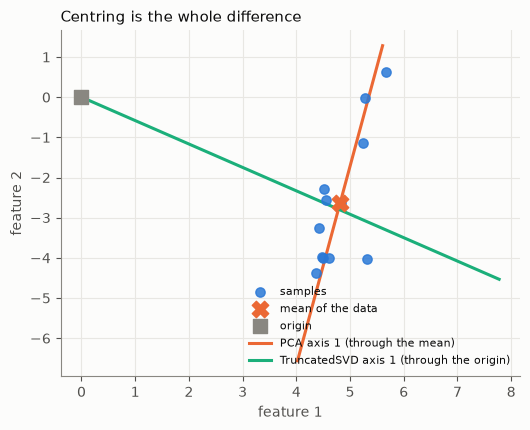

In [11]:
# Same picture in 2D: the leading axis of PCA and of an uncentred SVD point elsewhere.
X2 = X[:, :2]
X2c = X2 - X2.mean(0)
p2 = PCA(2, svd_solver="full").fit(X2)
t2 = TruncatedSVD(2, random_state=RANDOM_STATE).fit(X2)

fig, ax = plt.subplots(figsize=(5.4, 4.4))
ax.scatter(X2[:, 0], X2[:, 1], s=45, color=C_BLUE, alpha=0.85, zorder=3, label="samples")
ax.scatter(*X2.mean(0), s=140, marker="X", color=C_ORANGE, zorder=4, label="mean of the data")
ax.scatter(0, 0, s=90, marker="s", color=MUTED, zorder=4, label="origin")

scale = 4.0
c = X2.mean(0)
v_pca = p2.components_[0]
ax.plot([c[0] - scale * v_pca[0], c[0] + scale * v_pca[0]],
        [c[1] - scale * v_pca[1], c[1] + scale * v_pca[1]],
        color=C_ORANGE, lw=2.2, label="PCA axis 1 (through the mean)")
v_svd = t2.components_[0]
ax.plot([0, 9 * v_svd[0]], [0, 9 * v_svd[1]], color=C_AQUA, lw=2.2,
        label="TruncatedSVD axis 1 (through the origin)")

ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("Centring is the whole difference", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 2c. Why the uncentred variant exists at all: sparse data

Centring a sparse matrix destroys its sparsity — every structural zero becomes
$-\bar{x}_j$ — which is why `TruncatedSVD` (and not `PCA`) is the tool for
term–document / user–item matrices, exactly the setting of README task 2.

In [12]:
S = sp.random(2000, 3000, density=0.005, random_state=RANDOM_STATE, format="csr")
sparse_mb = (S.data.nbytes + S.indices.nbytes + S.indptr.nbytes) / 1e6
dense_mb = S.shape[0] * S.shape[1] * 8 / 1e6
nnz_after = np.count_nonzero(np.asarray(S.todense()) - np.asarray(S.mean(axis=0)))

print(f"shape                    : {S.shape}")
print(f"non-zeros as stored      : {S.nnz:,}  ({sparse_mb:.2f} MB, CSR)")
print(f"non-zeros after centring : {nnz_after:,}  ({dense_mb:.1f} MB, dense) "
      f"-> {dense_mb / sparse_mb:.0f}x more memory")

shape                    : (2000, 3000)
non-zeros as stored      : 30,000  (0.37 MB, CSR)
non-zeros after centring : 6,000,000  (48.0 MB, dense) -> 130x more memory


**Answer 2.** **SVD is a matrix factorisation; PCA is a statistical procedure that uses
it.** They are not competing algorithms and they are not the same object.

The **SVD** is a pure linear-algebra fact about *any* real matrix
$M_{n\times m} = U\Sigma V^\top$ with $U,V$ orthonormal and $\Sigma$ diagonal with
non-negative entries. It always exists, it is essentially unique (up to signs and ties),
it needs no assumptions about the data, and the Eckart–Young theorem guarantees that
truncating it at rank $k$ gives the best rank-$k$ approximation of $M$ in the Frobenius
norm.

**PCA** is a *statistical* method: it looks for the orthogonal directions along which the
sample **variance** of the data is maximal. Variance is defined about the mean, so PCA
first **centres** the data, $X_c = X - \bar{x}$, and only then factorises. Its principal
directions are the eigenvectors of the sample covariance matrix
$C = \frac{1}{n-1} X_c^\top X_c$, and because $X_c = U\Sigma V^\top$ implies
$C = V \frac{\Sigma^2}{n-1} V^\top$, those eigenvectors **are** the right singular vectors
of the centred matrix and the eigenvalues **are** $s_i^2/(n-1)$. The notebook verifies
exactly this: `pca.components_` equals `Vt` up to sign, `pca.explained_variance_` equals
`s**2/(n-1)`, `pca.transform(X)` equals $U\Sigma$, and the eigendecomposition of
`np.cov` reproduces both.

So the differences are:

- **Scope.** SVD applies to any matrix and carries no notion of samples, features, means
  or variance. PCA interprets rows as observations and columns as random variables, and
  therefore has a `mean_`, an `explained_variance_` and an `explained_variance_ratio_`.
- **Centring.** This is the operational difference. PCA subtracts the column means;
  a raw SVD does not. Where the mean is far from the origin the two give different first
  directions — above, $|\cos|$ between the uncentred first component and the mean vector
  is $\approx 0.9997$, i.e. the leading "component" merely encodes the data's offset,
  while PCA's leading component ignores that offset and maximises the variance *about the
  mean* ($|\cos|$ with the mean direction is only $0.39$). Feed `TruncatedSVD` the centred
  matrix and it reproduces `PCA` exactly.
- **Scaling.** PCA is *not* scale-invariant: variance is measured in the units of each
  feature, so a column in millimetres dominates the same column in metres. Standardising
  (`StandardScaler`) before PCA turns the covariance matrix into the **correlation**
  matrix; that is a modelling choice, not a detail. SVD as such says nothing about it.
- **Implementation and numerical stability.** scikit-learn's `PCA` never builds
  $X_c^\top X_c$. It calls LAPACK's `gesdd` on $X_c$ (`svd_solver="full"`), or a
  randomised range-finder (`"randomized"`, Halko et al.) / ARPACK for a few components
  on big matrices. The reason is conditioning: forming the Gram matrix squares the
  condition number. On the Läuchli matrix above, the true singular values
  $(1.732, 10^{-8}, 10^{-8})$ come out of `svd` correctly, while going through
  `eigvalsh(X.T @ X)` returns $(1.732, 2.7\cdot 10^{-9}, 0)$ — the small directions are
  destroyed, and $\mathrm{cond}(X^\top X)$ is reported as infinite where
  $\mathrm{cond}(X) \approx 1.7\cdot 10^8$. There is also a cost argument: for $n \gg m$
  or a truncation to $k \ll m$ components, a truncated/randomised SVD is far cheaper than
  a full eigendecomposition of a $m\times m$ covariance matrix.
- **`TruncatedSVD` vs `PCA` in the library.** They are the same computation minus the
  centring step, and that omission is deliberate: on the 2000×3000 sparse matrix above,
  subtracting the column means turns 30 000 stored non-zeros (0.37 MB CSR) into
  6 000 000 (48 MB dense), a 130× blow-up. For user–item or TF-IDF matrices centring is
  simply not affordable, so `TruncatedSVD` works on the raw matrix and accepts that its
  first component captures the mean. (When applied to a TF-IDF matrix this is exactly
  Latent Semantic Analysis.)

**Rule of thumb.** Dense data that fits in memory, and a variance interpretation is
wanted → `PCA`. Large sparse data that must not be densified → `TruncatedSVD`. Both are "an SVD" underneath;
the difference is centring and the statistical vocabulary built on top of it.

## Question 3. What is the difference between NMF and SVD?

`load_digits` is a natural test bed: pixel intensities are non-negative (0…16), so both
factorisations apply. Both are fitted at rank 16 and their learned components are drawn
as $8\times8$ images.

In [13]:
X_img = load_digits().data           # (1797, 64), values in [0, 16], strictly non-negative
print("shape:", X_img.shape, "| min:", X_img.min(), "| max:", X_img.max())

K = 16
t0 = time.perf_counter()
nmf = NMF(n_components=K, init="nndsvda", solver="cd", max_iter=600,
          tol=1e-4, random_state=RANDOM_STATE).fit(X_img)
t_nmf = time.perf_counter() - t0

t0 = time.perf_counter()
svd = TruncatedSVD(n_components=K, random_state=RANDOM_STATE).fit(X_img)
t_svd = time.perf_counter() - t0

W_nmf, H_nmf = nmf.transform(X_img), nmf.components_
X_nmf = W_nmf @ H_nmf
X_svd = svd.inverse_transform(svd.transform(X_img))

print(f"\nNMF : {t_nmf:.2f}s, {nmf.n_iter_} iterations (iterative, non-convex)")
print(f"SVD : {t_svd:.2f}s, direct (one randomised factorisation, no iteration to a local optimum)")
print(f"\nmin(H_nmf) = {H_nmf.min():.4f}, min(W_nmf) = {W_nmf.min():.4f}   -> both factors >= 0")
print(f"min(V_svd) = {svd.components_.min():.4f}  "
      f"({(svd.components_ < 0).mean():.0%} of the SVD loadings are negative)")

shape: (1797, 64) | min: 0.0 | max: 16.0



NMF : 0.37s, 480 iterations (iterative, non-convex)
SVD : 0.11s, direct (one randomised factorisation, no iteration to a local optimum)

min(H_nmf) = 0.0000, min(W_nmf) = 0.0000   -> both factors >= 0
min(V_svd) = -0.3781  (45% of the SVD loadings are negative)


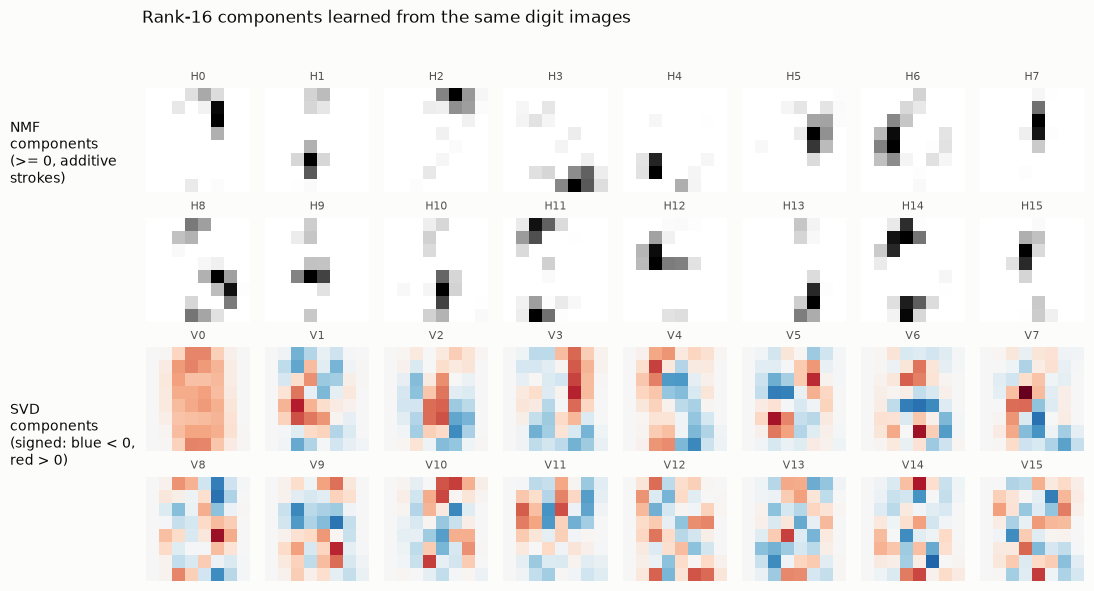

In [14]:
fig, axes = plt.subplots(4, 8, figsize=(11, 6))
vmax_svd = np.abs(svd.components_).max()

for j in range(K):
    ax = axes[j // 8, j % 8]
    ax.imshow(H_nmf[j].reshape(8, 8), cmap="gray_r")
    ax.set_axis_off()
    ax.set_title(f"H{j}", fontsize=8, color=INK2)

for j in range(K):
    ax = axes[2 + j // 8, j % 8]
    ax.imshow(svd.components_[j].reshape(8, 8), cmap="RdBu_r", vmin=-vmax_svd, vmax=vmax_svd)
    ax.set_axis_off()
    ax.set_title(f"V{j}", fontsize=8, color=INK2)

fig.text(0.01, 0.74, "NMF\ncomponents\n(>= 0, additive\nstrokes)", fontsize=10, color=INK,
         va="center", ha="left")
fig.text(0.01, 0.27, "SVD\ncomponents\n(signed: blue < 0,\nred > 0)", fontsize=10, color=INK,
         va="center", ha="left")
fig.suptitle("Rank-16 components learned from the same digit images", fontsize=12, x=0.13,
             ha="left")
plt.tight_layout(rect=[0.12, 0, 1, 0.95])
plt.show()

In [15]:
# Reconstruction quality at equal rank: SVD is provably optimal in the Frobenius norm.
ranks = [2, 4, 8, 16, 32]
rows = []
for k in ranks:
    a = NMF(n_components=k, init="nndsvda", solver="cd", max_iter=600,
            tol=1e-4, random_state=RANDOM_STATE).fit(X_img)
    err_nmf = np.linalg.norm(X_img - a.transform(X_img) @ a.components_)
    b = TruncatedSVD(n_components=k, random_state=RANDOM_STATE).fit(X_img)
    err_svd = np.linalg.norm(X_img - b.inverse_transform(b.transform(X_img)))
    rows.append({"rank": k, "NMF ||X-WH||_F": err_nmf, "SVD ||X-X_k||_F": err_svd,
                 "NMF / SVD": err_nmf / err_svd})
err = pd.DataFrame(rows).set_index("rank")
print("SVD is never beaten (Eckart-Young):", bool((err["NMF / SVD"] >= 1 - 1e-9).all()))
err.round(3)

SVD is never beaten (Eckart-Young): True


,NMF ||X-WH||_F,SVD ||X-X_k||_F,NMF / SVD
rank,,,
2,1333.719,1332.574,1.001
4,1140.026,1108.069,1.029
8,937.216,853.249,1.098
16,674.799,572.962,1.178
32,352.901,269.657,1.309


SVD components: max |cos| between different components = 7.73e-16   -> orthonormal basis
NMF components: max |cos| between different components = 0.530, mean = 0.110   -> not orthogonal


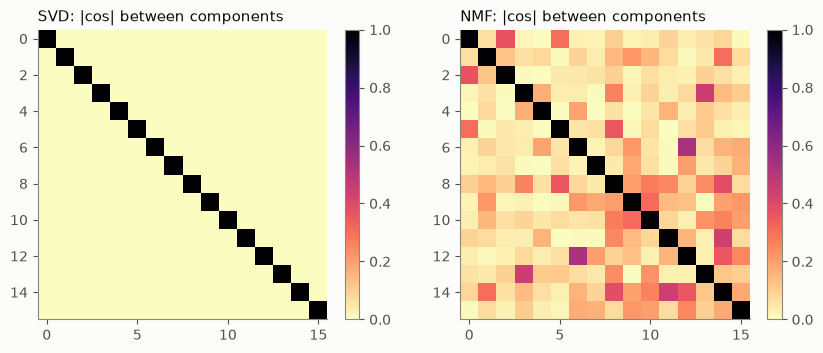

In [16]:
# Orthogonality, and whether rank-k factors are a prefix of rank-(k+1) factors.
def unit_rows(A):
    return A / np.linalg.norm(A, axis=1, keepdims=True)

G_svd = unit_rows(svd.components_) @ unit_rows(svd.components_).T
G_nmf = unit_rows(H_nmf) @ unit_rows(H_nmf).T
off = ~np.eye(K, dtype=bool)
print(f"SVD components: max |cos| between different components = {np.abs(G_svd[off]).max():.2e}"
      "   -> orthonormal basis")
print(f"NMF components: max |cos| between different components = {np.abs(G_nmf[off]).max():.3f}"
      f", mean = {np.abs(G_nmf[off]).mean():.3f}   -> not orthogonal")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6))
for ax, G, name in [(axes[0], G_svd, "SVD"), (axes[1], G_nmf, "NMF")]:
    im = ax.imshow(np.abs(G), cmap="magma_r", vmin=0, vmax=1)
    ax.set_title(f"{name}: |cos| between components", loc="left", fontsize=11)
    ax.grid(visible=False)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [17]:
# Nestedness: is the rank-2 solution the prefix of the rank-3 solution?
def cos_rows(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

nmf2 = NMF(2, init="nndsvda", solver="cd", max_iter=600, tol=1e-4,
           random_state=RANDOM_STATE).fit(X_img)
nmf3 = NMF(3, init="nndsvda", solver="cd", max_iter=600, tol=1e-4,
           random_state=RANDOM_STATE).fit(X_img)
svd2 = TruncatedSVD(2, random_state=RANDOM_STATE).fit(X_img)
svd3 = TruncatedSVD(3, random_state=RANDOM_STATE).fit(X_img)

nest = pd.DataFrame({
    "|cos| component 0, rank2 vs rank3": [abs(cos_rows(svd2.components_[0], svd3.components_[0])),
                                          abs(cos_rows(nmf2.components_[0], nmf3.components_[0]))],
    "|cos| component 1, rank2 vs rank3": [abs(cos_rows(svd2.components_[1], svd3.components_[1])),
                                          abs(cos_rows(nmf2.components_[1], nmf3.components_[1]))],
}, index=["SVD", "NMF"])
print(nest.round(4).to_string())

# Non-uniqueness: two random restarts of NMF land on different, equally good, factorisations.
runs = []
for seed in (0, 7):
    m = NMF(K, init="random", solver="cd", max_iter=600, tol=1e-4, random_state=seed).fit(X_img)
    runs.append(m)
best_match = [max(abs(cos_rows(h, g)) for g in runs[1].components_) for h in runs[0].components_]
print(f"\nNMF restarts (init='random', seeds 0 and 7):")
print(f"  ||X-WH||_F  = {runs[0].reconstruction_err_:.2f}  vs  {runs[1].reconstruction_err_:.2f}"
      "   (practically the same fit)")
print(f"  best |cos| match per component: mean {np.mean(best_match):.3f}, "
      f"min {np.min(best_match):.3f}   -> different bases")

     |cos| component 0, rank2 vs rank3  |cos| component 1, rank2 vs rank3
SVD                             1.0000                             1.0000
NMF                             0.9307                             0.9836



NMF restarts (init='random', seeds 0 and 7):
  ||X-WH||_F  = 674.06  vs  674.98   (practically the same fit)
  best |cos| match per component: mean 0.984, min 0.848   -> different bases


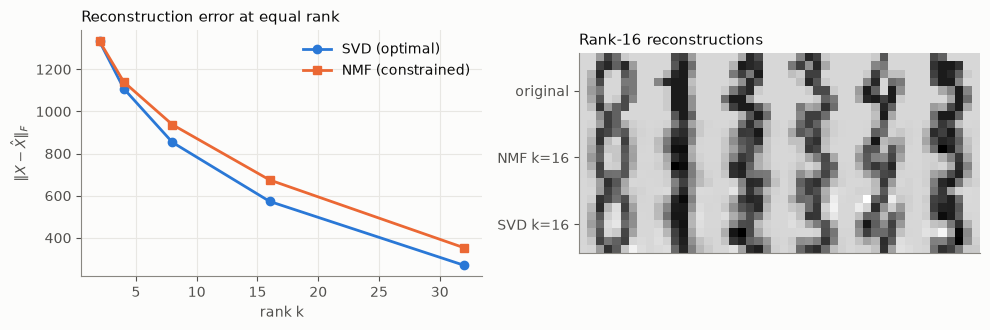

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

ax = axes[0]
ax.plot(err.index, err["SVD ||X-X_k||_F"], "o-", color=C_BLUE, lw=2, label="SVD (optimal)")
ax.plot(err.index, err["NMF ||X-WH||_F"], "s-", color=C_ORANGE, lw=2, label="NMF (constrained)")
ax.set_xlabel("rank k")
ax.set_ylabel(r"$\|X - \hat{X}\|_F$")
ax.set_title("Reconstruction error at equal rank", loc="left", fontsize=11)
ax.legend(frameon=False)

ax = axes[1]
sample = X_img[:6]
recon = {"original": sample,
         "NMF k=16": X_nmf[:6],
         "SVD k=16": X_svd[:6]}
strip = np.vstack([np.hstack([img.reshape(8, 8) for img in block]) for block in recon.values()])
ax.imshow(strip, cmap="gray_r")
ax.set_yticks([4, 12, 20])
ax.set_yticklabels(list(recon))
ax.set_xticks([])
ax.grid(visible=False)
ax.set_title("Rank-16 reconstructions", loc="left", fontsize=11)

plt.tight_layout()
plt.show()

**Answer 3.** Both write $X \approx AB$ with an inner dimension $k$, but they optimise
under completely different constraints, and the constraints are the whole story.

- **Non-negativity.** NMF requires $X\ge 0$ and produces $W\ge 0$, $H\ge 0$ — verified
  above, $\min W = \min H = 0$. SVD puts no sign constraint on $U$ and $V$;
  **45 % of the SVD loadings above are negative**. Consequently NMF is only defined for
  non-negative data — counts, TF-IDF, pixel intensities, spectra, ratings — while SVD
  works on any real matrix.
- **Orthogonality.** SVD's factors are orthonormal bases ($U^\top U = V^\top V = I$);
  measured above, the largest $|\cos|$ between two distinct SVD components is
  $\sim 10^{-16}$. NMF's components are merely non-negative vectors in the positive
  orthant, and vectors confined to one orthant cannot be mutually orthogonal in any
  useful way — the largest $|\cos|$ between two NMF components is $\mathbf{0.53}$ and
  the average is $0.11$, so the learned parts genuinely overlap (a stroke shared by two
  digits appears in several components).
- **Uniqueness and nestedness.** SVD is essentially unique and **nested**: the rank-2
  solution is literally the first two columns of the rank-3 solution
  ($|\cos| = 1.0000$ in the table). NMF minimises $\|X - WH\|_F^2$ subject to
  $W,H \ge 0$ — a problem that is convex in $W$ for fixed $H$ and vice versa, but **not
  jointly convex** — so it is solved iteratively (coordinate descent / multiplicative
  updates) and converges to a *local* optimum that depends on the initialisation. It is
  neither unique (two random restarts above reach the same reconstruction error with
  visibly different bases) nor nested ($|\cos|$ between rank-2 and rank-3 components is
  clearly below 1, so re-fitting is required for every new $k$). It is also invariant to
  $W\!D, D^{-1}\!H$ for any positive diagonal $D$, so the scale split between $W$ and $H$
  is a convention.
- **Optimality.** By Eckart–Young the truncated SVD is the *provably best* rank-$k$
  approximation in the Frobenius norm. NMF searches a strictly smaller feasible set
  (the non-negative factorisations), so at equal rank its error can never be smaller —
  the table confirms the ratio $\|X-WH\|_F / \|X-X_k\|_F \ge 1$ at every rank, growing
  from $\approx 1.00$ at $k=2$ to $\approx 1.3$ at $k=32$. **NMF trades reconstruction
  accuracy for interpretability.**
- **Interpretation — the reason to accept that trade.** The component images make it
  concrete. Because everything is additive and non-negative, an NMF component can only
  ever *add* ink: the learned $H_j$ are localised **strokes and parts** (a top bar, a
  left loop, a lower curve) and a digit is assembled as a positive weighted sum of parts —
  Lee & Seung's "learning the parts of objects". SVD components are signed *eigen-digits*:
  global, whole-image templates in which red and blue regions **cancel each other**, so
  an individual component is not something you can point at in the data. The same
  contrast is why NMF is the default for topic models on term–document matrices (a topic
  is a non-negative set of words; a document is a non-negative mixture of topics, with no
  "negative amount of a topic") and for recommender systems on non-negative ratings.

**When to use which.** Need the best compression, a rotationally-invariant orthogonal
basis, a deterministic result, or signed data → SVD/PCA. Need factors a human can read as
parts, topics or sources, and the data is non-negative → NMF, accepting a slightly worse
fit, an iterative fit with a `random_state`, and a re-fit for every rank.

## Question 4. The structure of the Locally Linear Embedding (LLE) algorithm

LLE is a **manifold-learning** method: it assumes the data lies on a low-dimensional
manifold that is *locally* (in a small neighbourhood) well approximated by a linear patch,
and it looks for a low-dimensional embedding that preserves those local linear relations.
It has exactly three steps:

**Step (a) — neighbourhoods.** For every point $x_i \in \mathbb{R}^D$ find its $k$ nearest
neighbours $\mathcal{N}(i)$ (Euclidean, k-d tree / ball tree).

**Step (b) — reconstruction weights.** Find weights $W$ that rebuild each point from its
neighbours as well as possible:

$$\mathcal{E}(W)=\sum_i \Big\| x_i - \sum_{j\in\mathcal{N}(i)} W_{ij}x_j \Big\|^2
\quad\text{s.t.}\quad \sum_j W_{ij}=1,\; W_{ij}=0 \text{ for } j\notin\mathcal{N}(i).$$

With $z_j = x_j - x_i$ and the **local Gram matrix** $C^{(i)}_{jl}=z_j^\top z_l$, the
closed-form solution of each little constrained least-squares problem is
$w \propto (C^{(i)})^{-1}\mathbf{1}$, rescaled so that $\sum_j w_j = 1$.

**Step (c) — the embedding.** Freeze $W$ and look for $y_i \in \mathbb{R}^d$, $d \ll D$,
minimising the *same* cost with the *same* weights:

$$\Phi(Y)=\sum_i \Big\| y_i-\sum_j W_{ij}y_j \Big\|^2 = \operatorname{tr}(Y^\top M Y),
\qquad M=(I-W)^\top (I-W),$$

subject to $\sum_i y_i = 0$ and $\frac{1}{n}Y^\top Y = I$ (which fix the otherwise free
translation, rotation and scale). By Rayleigh–Ritz the solution is the eigenvectors of
$M$ for the smallest eigenvalues — discarding the very smallest, whose eigenvector is the
constant vector $\mathbf{1}/\sqrt{n}$ with eigenvalue $0$ (it corresponds to the
translation freedom), and keeping eigenvectors $2 \ldots d+1$.

Everything below is verified numerically on a Swiss roll.

Swiss roll: (1500, 3) | ambient D = 3, intrinsic dimension = 2


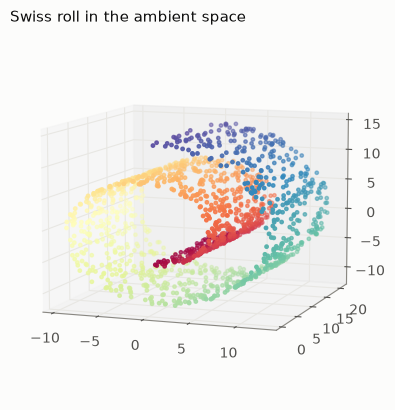

In [19]:
N_SWISS, K_NN, D_EMB = 1500, 12, 2
X_roll, t_roll = make_swiss_roll(n_samples=N_SWISS, noise=0.05, random_state=RANDOM_STATE)
print("Swiss roll:", X_roll.shape, "| ambient D = 3, intrinsic dimension = 2")

fig = plt.figure(figsize=(5.2, 4.2))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=t_roll, cmap="Spectral", s=6)
ax.set_title("Swiss roll in the ambient space", loc="left", fontsize=11)
ax.view_init(9, -70)
ax.set_facecolor(SURFACE)
plt.tight_layout()
plt.show()

### Step (b) implemented by hand

For a handful of points, and then for all of them, the barycentric weights are computed
from the definition and compared with scikit-learn's internal
`barycenter_kneighbors_graph`.

In [20]:
nn = NearestNeighbors(n_neighbors=K_NN + 1).fit(X_roll)
neighbors = nn.kneighbors(X_roll, return_distance=False)[:, 1:]   # drop the point itself
print("neighbour index matrix:", neighbors.shape)


def barycentric_weights(X, neighbors, reg=1e-3):
    "Step (b) of LLE: solve C w = 1 per point, then normalise so that sum(w) = 1."
    n, k = neighbors.shape
    W = np.empty((n, k))
    for i in range(n):
        Z = X[neighbors[i]] - X[i]              # neighbours, recentred on x_i
        C = Z @ Z.T                             # local Gram matrix, k x k
        C = C + np.eye(k) * reg * np.trace(C)   # regularisation, needed when k > D
        w = np.linalg.solve(C, np.ones(k))
        W[i] = w / w.sum()                      # enforce the sum-to-one constraint
    return W


t0 = time.perf_counter()
W_manual = barycentric_weights(X_roll, neighbors)
print(f"solved {len(X_roll)} local systems in {time.perf_counter() - t0:.2f}s")

print("\nweights of the first 3 points (k = 12 each):")
print(pd.DataFrame(W_manual[:3], index=[f"x_{i}" for i in range(3)],
                   columns=[f"w{j}" for j in range(K_NN)]).round(3).to_string())
print("\nrow sums (constraint sum_j W_ij = 1): min = "
      f"{W_manual.sum(1).min():.12f}, max = {W_manual.sum(1).max():.12f}")
print("some weights are negative:", bool((W_manual < 0).any()),
      f"({(W_manual < 0).mean():.0%} of them) - W is a barycentric, not a convex, combination")

neighbour index matrix: (1500, 12)
solved 1500 local systems in 0.03s

weights of the first 3 points (k = 12 each):
        w0     w1     w2     w3     w4     w5     w6     w7     w8     w9    w10    w11
x_0  0.159  0.163  0.083  0.200  0.152  0.109  0.017  0.014  0.094  0.043 -0.055  0.020
x_1  0.129  0.126  0.076  0.107  0.092  0.082  0.194  0.074  0.057 -0.101  0.122  0.043
x_2  0.494  0.329  0.158  0.128  0.067 -0.058  0.027 -0.113  0.036 -0.005 -0.087  0.024

row sums (constraint sum_j W_ij = 1): min = 1.000000000000, max = 1.000000000000
some weights are negative: True (14% of them) - W is a barycentric, not a convex, combination


In [21]:
# 1) our weights == scikit-learn's
W_dense = np.zeros((len(X_roll), len(X_roll)))
np.put_along_axis(W_dense, neighbors, W_manual, axis=1)
W_sklearn = barycenter_kneighbors_graph(X_roll, K_NN, reg=1e-3).toarray()
print(f"max |W_manual - W_sklearn| = {np.abs(W_dense - W_sklearn).max():.3e}")

# 2) the reconstruction is genuinely accurate
recon = np.einsum("ij,ijk->ik", W_manual, X_roll[neighbors])
res = np.linalg.norm(recon - X_roll, axis=1)
print(f"mean ||x_i - sum_j W_ij x_j||   = {res.mean():.5f}"
      f"   (mean ||x_i|| = {np.linalg.norm(X_roll, axis=1).mean():.3f})")

# 3) the sum-to-one constraint makes W invariant to rotation, rescaling and translation
Q, _ = np.linalg.qr(np.random.default_rng(0).standard_normal((3, 3)))   # random rotation
X_transformed = (X_roll @ Q.T) * 2.5 + np.array([10.0, -3.0, 7.0])      # + scale + shift
W_transformed = barycentric_weights(X_transformed, neighbors)
print(f"max |W(X) - W(2.5 * X @ Q.T + b)| = {np.abs(W_manual - W_transformed).max():.3e}"
      "   -> locally invariant, hence 'locally linear'")

# 4) why the regularisation term is required when k > D
i = 0
Z0 = X_roll[neighbors[i]] - X_roll[i]
C0 = Z0 @ Z0.T
print(f"\nlocal Gram matrix C: shape {C0.shape}, rank {np.linalg.matrix_rank(C0)} "
      f"(<= D = {X_roll.shape[1]}) because k = {K_NN} > D")
print(f"cond(C) without regularisation = {np.linalg.cond(C0):.2e}   -> singular, w is undetermined")
print(f"cond(C + 1e-3 * trace(C) * I)  = "
      f"{np.linalg.cond(C0 + np.eye(K_NN) * 1e-3 * np.trace(C0)):.2e}   -> solvable, "
      "and the ridge picks the smallest-norm (smoothest) weights")

max |W_manual - W_sklearn| = 1.843e-14
mean ||x_i - sum_j W_ij x_j||   = 0.02815   (mean ||x_i|| = 14.898)
max |W(X) - W(2.5 * X @ Q.T + b)| = 1.985e-14   -> locally invariant, hence 'locally linear'

local Gram matrix C: shape (12, 12), rank 3 (<= D = 3) because k = 12 > D
cond(C) without regularisation = 6.81e+17   -> singular, w is undetermined
cond(C + 1e-3 * trace(C) * I)  = 6.29e+02   -> solvable, and the ridge picks the smallest-norm (smoothest) weights


### Step (c) implemented by hand — the eigenvector problem

$M=(I-W)^\top(I-W)$ is built explicitly, `scipy.linalg.eigh` returns its smallest
eigenpairs, the constant eigenvector is inspected and discarded, and the resulting
embedding is compared with `sklearn.manifold.LocallyLinearEmbedding`.

In [22]:
n = len(X_roll)
I_minus_W = np.eye(n) - W_dense
M = I_minus_W.T @ I_minus_W

t0 = time.perf_counter()
eigvals_M, eigvecs_M = eigh(M, subset_by_index=[0, D_EMB])     # d + 1 smallest eigenpairs
print(f"eigendecomposition of M ({M.shape}) in {time.perf_counter() - t0:.2f}s")
print("smallest eigenvalues of M:", eigvals_M)

null_vec = eigvecs_M[:, 0]
print(f"\neigenvector 1: mean = {null_vec.mean():.6f}  (= -1/sqrt(n) = {-1/np.sqrt(n):.6f}), "
      f"std = {null_vec.std():.2e}")
print("   -> it is the constant vector 1/sqrt(n) with eigenvalue ~ 0; DISCARDED")

Y_manual = eigvecs_M[:, 1:D_EMB + 1]                            # eigenvectors 2 .. d+1
print(f"\nembedding constraints: mean = {np.abs(Y_manual.mean(0)).max():.2e} (~ 0), "
      f"Y^T Y = I -> {np.allclose(Y_manual.T @ Y_manual, np.eye(D_EMB))}")

eigendecomposition of M ((1500, 1500)) in 0.32s
smallest eigenvalues of M: [-1.20799743e-16  1.24966441e-09  8.43150975e-08]

eigenvector 1: mean = -0.025820  (= -1/sqrt(n) = -0.025820), std = 3.07e-09
   -> it is the constant vector 1/sqrt(n) with eigenvalue ~ 0; DISCARDED

embedding constraints: mean = 3.07e-09 (~ 0), Y^T Y = I -> True


In [23]:
lle = LocallyLinearEmbedding(n_neighbors=K_NN, n_components=D_EMB, reg=1e-3,
                             method="standard", random_state=RANDOM_STATE)
Y_sklearn = lle.fit_transform(X_roll)

# the embedding is only defined up to an orthogonal transform -> align before comparing
A = Y_manual / np.linalg.norm(Y_manual)
B = Y_sklearn / np.linalg.norm(Y_sklearn)
R, _ = orthogonal_procrustes(A, B)
print(f"residual after optimal rotation, manual vs sklearn = {np.linalg.norm(A @ R - B):.3e}")
print(f"sklearn reconstruction_error_                      = {lle.reconstruction_error_:.3e}")

rho_manual = spearmanr(Y_manual[:, 0], t_roll).statistic
rho_sklearn = spearmanr(Y_sklearn[:, 0], t_roll).statistic
print(f"\nSpearman(embedding axis 1, roll parameter t): manual {rho_manual:+.4f}, "
      f"sklearn {rho_sklearn:+.4f}   -> the roll is unrolled")

residual after optimal rotation, manual vs sklearn = 8.484e-08
sklearn reconstruction_error_                      = 8.556e-08

Spearman(embedding axis 1, roll parameter t): manual -0.9999, sklearn -0.9999   -> the roll is unrolled


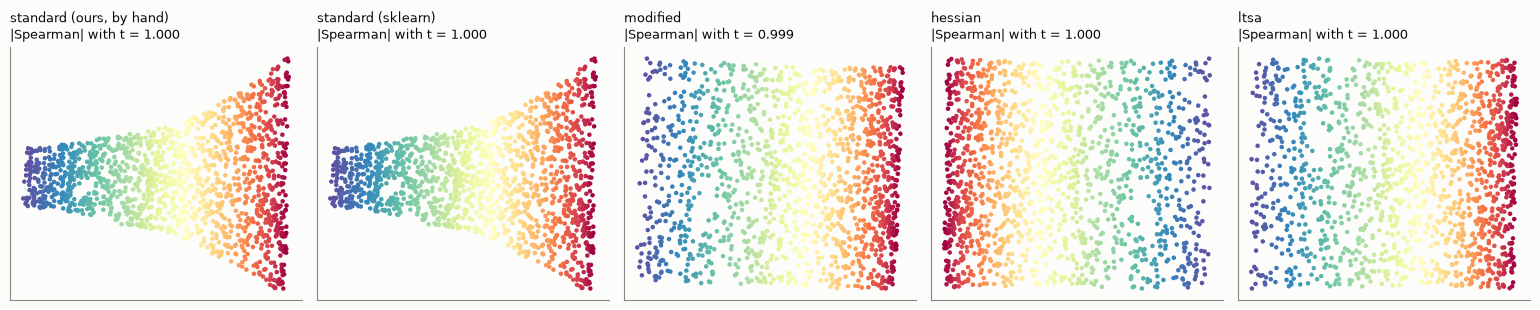

In [24]:
variants = {"standard (ours, by hand)": Y_manual, "standard (sklearn)": Y_sklearn}
for method in ["modified", "hessian", "ltsa"]:
    variants[method] = LocallyLinearEmbedding(
        n_neighbors=K_NN, n_components=D_EMB, method=method,
        random_state=RANDOM_STATE).fit_transform(X_roll)

fig, axes = plt.subplots(1, len(variants), figsize=(3.1 * len(variants), 3.2))
for ax, (name, Y) in zip(axes, variants.items()):
    ax.scatter(Y[:, 0], Y[:, 1], c=t_roll, cmap="Spectral", s=5)
    rho = abs(spearmanr(Y[:, 0], t_roll).statistic)
    ax.set_title(f"{name}\n|Spearman| with t = {rho:.3f}", loc="left", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(visible=False)
plt.tight_layout()
plt.show()

**Answer 4.** LLE (Roweis & Saul, 2000) assumes that a smooth manifold looks linear at a
small enough scale, so each point can be written as a linear combination of its
neighbours; the coefficients of that combination characterise the local geometry, and LLE
looks for the low-dimensional configuration that reproduces them. Its structure is three
steps, and only the first is a choice of hyper-parameter — the other two have closed-form
solutions.

**(a) Neighbourhood selection.** For each $x_i \in \mathbb{R}^D$ collect the $k$ nearest
neighbours (or all points inside a radius $\varepsilon$). This is the only place where the
global geometry enters, and $k$ is the critical hyper-parameter: too small and the graph
disconnects and the embedding shatters; too large and the "neighbourhood" wraps across
the fold of the manifold and the local linearity assumption breaks. Cost
$O(D n \log n)$ with a k-d tree.

**(b) Reconstruction weights $W$ — a constrained least squares per point.** Minimise
$\mathcal{E}(W)=\sum_i \|x_i-\sum_j W_{ij}x_j\|^2$ subject to $\sum_j W_{ij}=1$ and
$W_{ij}=0$ outside $\mathcal{N}(i)$. Because only the neighbours of $i$ appear, the
problem decouples into $n$ tiny problems of size $k$. Writing
$x_i - \sum_j w_j x_j = -\sum_j w_j (x_j - x_i)$ using the sum-to-one constraint, the
objective becomes $w^\top C^{(i)} w$ with the local Gram matrix
$C^{(i)}_{jl}=(x_j-x_i)^\top(x_l-x_i)$; a Lagrange multiplier gives
$w \propto (C^{(i)})^{-1}\mathbf{1}$, normalised to sum to one — which is exactly what
`barycentric_weights` above implements, matching scikit-learn to $\sim 10^{-14}$.
Two details of this step matter:
  - **sum-to-one** makes $w$ a *barycentric* (not convex — 14 % of our weights are
    negative) combination, and this is what makes $W$ invariant to **translation**;
    invariance to **rotation and rescaling** follows because the objective only involves
    the Gram matrix. The notebook verifies all three at once: applying a random rotation,
    a $2.5\times$ scaling and a shift to the whole cloud changes the weights by
    $\sim 10^{-14}$. $W$ therefore encodes *intrinsic* local geometry — the property that
    licenses reusing the same $W$ in a completely different space in step (c), and the
    reason the method is called "locally **linear**".
  - **regularisation.** When $k > D$ (here $k=12 > D=3$) the $k\times k$ matrix
    $C^{(i)}$ has rank at most $D$ and is singular — measured above, rank 3 and
    $\mathrm{cond}(C)\approx 7\cdot 10^{17}$ — so the weights are undetermined. LLE adds
    $C \leftarrow C + \delta\,\mathrm{tr}(C)\,I$ with a small $\delta$ (scikit-learn's
    `reg=1e-3`), which restores conditioning to $\sim 6\cdot 10^{2}$ and selects the
    minimum-norm, i.e. smoothest and most evenly spread, solution among all exact
    reconstructions.

**(c) Embedding $Y$ — a sparse eigenproblem.** Hold $W$ fixed and minimise the *same*
cost over the low-dimensional coordinates:
$\Phi(Y)=\sum_i\|y_i-\sum_j W_{ij}y_j\|^2=\operatorname{tr}(Y^\top M Y)$ with
$M=(I-W)^\top(I-W)$, a sparse, symmetric, positive-semidefinite $n\times n$ matrix.
$\Phi$ is invariant to translations and has the trivial minimiser $Y=0$, so two
constraints are imposed: $\sum_i y_i = 0$ (centring) and $\frac{1}{n}Y^\top Y=I$ (unit
covariance, which also removes the rotational degeneracy). By the Rayleigh–Ritz theorem
the minimiser is spanned by the eigenvectors of $M$ belonging to the $d+1$ **smallest**
eigenvalues; the very smallest is $\lambda_1 = 0$ with the constant eigenvector
$\mathbf{1}/\sqrt{n}$ — confirmed above: $\lambda_1 \approx -10^{-16}$, the eigenvector
has mean $-1/\sqrt{n}$ and standard deviation $\sim 10^{-9}$ — and it is **discarded**
because it is exactly the translation freedom the centring constraint forbids.
Eigenvectors $2,\dots,d+1$ are the embedding. Our hand-built version matches
scikit-learn's to $\sim 10^{-8}$ after the (expected) orthogonal alignment, and both
achieve $|\rho_{\text{Spearman}}| \approx 0.9999$ between the first embedding coordinate
and the true Swiss-roll parameter $t$: the roll is unrolled.

**Properties and variants.** LLE needs no iterative optimisation and has no local minima
(unlike t-SNE/UMAP) — everything is a linear solve plus one eigenproblem — and cost is
dominated by the sparse eigendecomposition, $O(dn^2)$ in the worst case (ARPACK/LOBPCG in
practice). Its weaknesses are the sensitivity to $k$, the regularisation parameter, and
a tendency to collapse regions of the manifold; hence the variants scikit-learn exposes
through `method=`:
  - **modified LLE (MLLE)** uses *multiple* weight vectors per neighbourhood (the whole
    null space of $C^{(i)}$ instead of one arbitrary regularised solution), which removes
    the regularisation sensitivity;
  - **Hessian LLE (HLLE)** replaces the reconstruction cost by an estimate of the local
    Hessian (curvature) functional and is provably correct on non-convex parameter
    domains, at a higher cost and requiring $k > d(d+3)/2$;
  - **LTSA** (Local Tangent Space Alignment) fits a local tangent space (a small PCA) at
    each point and glues the local coordinate charts together.

The panel above shows all four side by side: standard LLE unrolls the roll but compresses
it unevenly, while MLLE / HLLE / LTSA return a much more uniform rectangular sheet, each
with $|\rho| \approx 1$ against the true roll parameter.

## Summary

| Question | What the notebook computes | Take-away |
|---|---|---|
| 1. Curse of dimensionality | contrast $(d_{\max}-d_{\min})/d_{\min}$ vs $d$; accuracy of 7 models vs 0…1024 noise features | distance/kernel models (k-NN, SVM-RBF) collapse; linear models suffer through coefficient variance; trees & ensembles are robust because splits are univariate; Gaussian NB is flat because it never models interactions |
| 2. PCA vs SVD | `PCA.components_ == V^T` of the centred matrix, `explained_variance_ == s²/(n-1)`; Läuchli matrix; sparse-centring memory blow-up | PCA = SVD of the **mean-centred** matrix, plus a variance vocabulary; the SVD route is used because forming $X^\top X$ squares the condition number; `TruncatedSVD` skips centring to keep sparsity |
| 3. NMF vs SVD | rank-16 components as images; $\|X-\hat X\|_F$ vs rank; component Gram matrices; rank-2 vs rank-3 nesting; random restarts | NMF: non-negative, non-orthogonal, non-unique, non-nested, iterative, additive **parts**; SVD: signed, orthogonal, unique, nested, direct, and provably optimal at every rank |
| 4. LLE | hand-written barycentric weights (matching sklearn to $10^{-14}$), invariance check, singular local Gram matrix, hand-built $M=(I-W)^\top(I-W)$ eigenproblem | three steps: neighbours → sum-to-one reconstruction weights → eigenvectors 2…d+1 of $M$; the constant eigenvector is dropped, regularisation is needed whenever $k>D$ |

In [25]:
print(f"notebook runtime: {time.perf_counter() - NB_START:.1f} s")

notebook runtime: 53.4 s
